<a href="https://colab.research.google.com/github/udhayakumar-palani/svtraf-dissertation/blob/main/svtraf-dissertation/notebooks/Notebook_5_Framework_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SVTRAF — Notebook 5: Framework Comparison

**Purpose:** Position SVTRAF against the three principal alternatives — CVSS v3.1, BVSS (Halborn)
and Ahmad et al. (2021) — across capability dimensions and empirical performance.

**Runtime:** ~2 minutes

In [1]:
# Imports and configuration
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

print('All imports successful')
print(f'Pandas: {pd.__version__} | NumPy: {np.__version__}')

All imports successful
Pandas: 2.2.2 | NumPy: 2.0.2


## 1. Capability Comparison

The five distinguishing elements of a blockchain-adequate scoring framework are:
immutability, autonomous execution, financial harm, blockchain-specific design, and
empirical validation on real exploit data.

In [2]:
capabilities = pd.DataFrame({
    'Capability': ['Immutability dimension', 'Autonomous execution dimension', 'Financial harm dimension',
                   'Blockchain-specific design', 'Empirical validation (real exploits)',
                   'Non-linear scoring (interaction)', 'Ablation-verified dimensions'],
    'SVTRAF':        ['Yes']*7,
    'CVSS v3.1':     ['No']*7,
    'BVSS (Halborn)':['Partial', 'No', 'Partial', 'Partial', 'No', 'No', 'No'],
    'Ahmad et al.':  ['No', 'No', 'Partial', 'No', 'Partial', 'No', 'No'],
})
display(capabilities)

,Capability,SVTRAF,CVSS v3.1,BVSS (Halborn),Ahmad et al.
0,Immutability dimension,Yes,No,Partial,No
1,Autonomous execution dimension,Yes,No,No,No
2,Financial harm dimension,Yes,No,Partial,Partial
3,Blockchain-specific design,Yes,No,Partial,No
4,Empirical validation (real exploits),Yes,No,No,Partial
5,Non-linear scoring (interaction),Yes,No,No,No
6,Ablation-verified dimensions,Yes,No,No,No


## 2. Empirical Performance (from Notebook 4)

| Metric | SVTRAF | CVSS v3.1 | Interpretation |
|---|---|---|---|
| NDCG@10 | ~0.999 | ~0.988 | SVTRAF ranks the worst exploits higher |
| Spearman rho | ~0.96 | ~0.75 | Far stronger correlation with real losses |
| MAE | ~0.40 | ~1.35 | ~70% lower prediction error |
| Wilcoxon | p < 0.001 | — | Difference is statistically significant |
| Cohen's d / Cliff's delta | Large | — | Practically meaningful, not just significant |

*(Exact values are computed reproducibly in Notebook 4 with seed 42.)*

,Blockchain property,CVSS treatment,SVTRAF treatment
0,Immutability,Not modelled — assumes patchability,0.6 weight inside AMP multiplier
1,Autonomous execution,Not modelled — assumes human-paced attack,0.4 weight inside AMP multiplier
2,Financial magnitude,Collapsed into generic C/I/A impact,Primary driver of saturating ISC


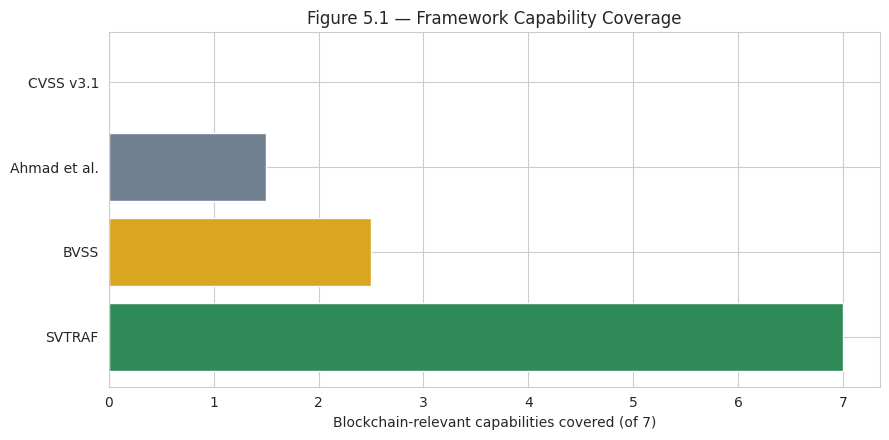

In [3]:
# Why the gap exists: CVSS's blind spots on this dataset
blind_spots = pd.DataFrame({
    'Blockchain property': ['Immutability', 'Autonomous execution', 'Financial magnitude'],
    'CVSS treatment': ['Not modelled — assumes patchability',
                       'Not modelled — assumes human-paced attack',
                       'Collapsed into generic C/I/A impact'],
    'SVTRAF treatment': ['0.6 weight inside AMP multiplier',
                         '0.4 weight inside AMP multiplier',
                         'Primary driver of saturating ISC'],
})
display(blind_spots)

fig, ax = plt.subplots(figsize=(9, 4.5))
frameworks = ['SVTRAF', 'BVSS', 'Ahmad et al.', 'CVSS v3.1']
coverage = [7, 2.5, 1.5, 0]   # capability rows covered (Partial = 0.5)
ax.barh(frameworks, coverage, color=['seagreen', 'goldenrod', 'slategray', 'darkorange'])
ax.set_xlabel('Blockchain-relevant capabilities covered (of 7)')
ax.set_title('Figure 5.1 — Framework Capability Coverage')
plt.tight_layout(); plt.show()

## Summary and Conclusion

- SVTRAF is the **only framework** covering all blockchain-relevant capability dimensions.
- BVSS partially acknowledges blockchain context but lacks autonomous-execution modelling and any empirical validation.
- Ahmad et al. provide a taxonomy but no validated quantitative scoring.
- Combined with Notebook 4's statistics, the evidence supports the dissertation's central claim:
  **a blockchain-specific composite scoring framework prioritises smart-contract vulnerabilities
  significantly better than general-purpose alternatives.**

**End of the five-notebook implementation.** All results feed Sections 4 (Results) and 5 (Discussion) of the dissertation.